# 📈 Stockholm — 주식 기술적 분석 & 백테스팅

**데이터 소스**: 네이버 금융 (한국 주식) / Yahoo Finance (해외 주식)

**주요 기능**
- 퍼지 종목명 검색
- SMA / EMA / RSI / MACD / 볼린저밴드
- 지지선 / 저항선 / 추세선 자동 탐지
- 전략 백테스팅 및 수익률 리포트
- 통합 시각화 대시보드

In [1]:
# 라이브러리 임포트
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data.krx_fetcher import fetch_krx_list, get_korean_stock
from data.yahoo_fetcher import get_us_stock
from analysis.indicators import add_all_indicators
from analysis.patterns import find_support_resistance, find_trendlines
from strategy.ma_crossover import SMACrossover, EMACrossover, SMAEMACrossover
from analysis.backtester import Backtester
from visualization.plotter import (
    plot_dashboard,
    plot_price_signals,
    plot_support_resistance,
    plot_trendlines,
    plot_rsi,
    plot_macd,
    plot_backtest,
)
from utils.search import fuzzy_search_company

print("✅ 모든 모듈 임포트 완료!")

✅ 모든 모듈 임포트 완료!


## 1. 데이터 수집

In [2]:
# KRX 종목 목록 로드
print("KRX 종목 목록 로딩 중...")
krx_df = fetch_krx_list()
print(f"총 {len(krx_df)}개 종목 로드 완료!")
krx_df.head()

KRX 종목 목록 로딩 중...
총 2766개 종목 로드 완료!


,code,company
0,493280,아이엠바이오로직스
1,0082N0,카나프테라퓨틱스
2,0011A0,액스비스
3,458350,에스팀
4,279570,케이뱅크


In [3]:
# 퍼지 종목명 검색
query = "삼성전"
results = fuzzy_search_company(query, krx_df)
print(f"'{query}' 검색 결과:")
results

'삼성전' 검색 결과:


,code,company,score
0,009150,삼성전기,93.714286
1,005930,삼성전자,93.714286
2,006660,삼성공조,57.142857
3,028260,삼성물산,57.142857
4,032830,삼성생명,57.142857


In [4]:
# 종목 선택 및 데이터 fetch
COMPANY = "삼성전자"
print(f"{COMPANY} 데이터 불러오는 중...")
df_kr = get_korean_stock(COMPANY, krx_df)
print(f"데이터 로드 완료! ({len(df_kr)}일치)")
df_kr.tail()

삼성전자 데이터 불러오는 중...
데이터 로드 완료! (2500일치)


,open,high,low,close,volume
date,,,,,
2026-03-16,184600,189000,183600,188700,19747901
2026-03-17,198000,198000,193100,193900,20300082
2026-03-18,200500,209000,199700,208500,25148481
2026-03-19,199900,205000,199600,200500,19884483
2026-03-20,202000,202500,199000,199400,25527507


In [5]:
# 해외 주식 데이터 fetch
TICKER = "AAPL"
print(f"{TICKER} 데이터 불러오는 중...")
df = get_us_stock(TICKER, years=3)
print(f"데이터 로드 완료! ({len(df)}일치)")
df.tail()

AAPL 데이터 불러오는 중...
데이터 로드 완료! (753일치)


,open,high,low,close,volume
date,,,,,
2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200
2026-03-17,252.960007,255.130005,252.179993,254.229996,32361600
2026-03-18,252.630005,254.940002,249.000000,249.940002,35757900
2026-03-19,249.399994,251.830002,247.300003,248.960007,34864100
2026-03-20,248.110001,249.199905,246.000000,247.990005,87981315


## 2. 기술적 지표 계산

In [6]:
# 모든 지표 한번에 추가
df = add_all_indicators(df)

# 지표 확인
cols = ["close", "SMA_20", "SMA_50", "EMA_12", "RSI_14", "MACD", "BB_upper", "BB_lower"]
df[cols].tail(5)

,close,SMA_20,SMA_50,EMA_12,RSI_14,MACD,BB_upper,BB_lower
date,,,,,,,,
2026-03-16,252.820007,262.601499,262.204839,258.735571,38.715201,-2.937502,274.835233,250.367765
2026-03-17,254.229996,262.118999,261.874306,258.042405,40.815515,-3.079328,274.889825,249.348173
2026-03-18,249.940002,261.398499,261.532903,256.795882,36.694893,-3.497575,275.221931,247.575066
2026-03-19,248.960007,260.817500,261.269809,255.590363,35.805608,-3.863580,275.720410,245.914589
2026-03-20,247.990005,259.988000,261.027877,254.421077,34.903948,-4.183685,275.826571,244.149430


## 3. 전략 & 백테스팅

In [7]:
# 전략 선택 및 신호 생성
strategy = SMACrossover(short_window=20, long_window=60)
df_signals = strategy.generate_signals(df)

# 매수/매도 신호 확인
signals = df_signals[df_signals["signal"] != 0][["close", "signal"]]
print(f"총 {len(signals)}개 신호 발생")
signals.tail(10)

총 11개 신호 발생


,close,signal
date,,
2023-11-16,187.759476,1
2024-01-25,192.173599,-1
2024-05-14,185.991547,1
2024-11-26,233.782913,-1
2024-11-29,236.040573,1
2025-01-28,236.965546,-1
2025-07-10,211.765579,1
2026-01-12,260.006714,-1
2026-02-26,272.950012,1


In [8]:
# 백테스팅 실행
bt = Backtester(initial_capital=10_000_000)
df_result = bt.run(df_signals)

# 리포트 출력
bt.print_report()

  백테스팅 결과 리포트
  초기 투자금    :      10,000,000 원
  최종 자산      :       9,511,873 원
----------------------------------------
  전략 총 수익률 :          -4.88 %
  시장 총 수익률 :          36.58 %
  연간 수익률    :          -2.25 %
  최대 낙폭(MDD) :          -5.22 %
  승률           :          75.00 %
  총 거래 횟수   :              9 회
  샤프 지수      :          -0.78


In [9]:
# 전략 비교
strategies = [
    SMACrossover(50, 200),
    EMACrossover(50, 200),
    SMAEMACrossover(50),
]

print(f"{'전략':<25} {'수익률':>8} {'시장':>8} {'MDD':>8} {'승률':>8} {'거래':>6}")
print("-" * 70)
for s in strategies:
    df_s = s.generate_signals(df)
    bt_s = Backtester(initial_capital=10_000_000)
    bt_s.run(df_s)
    r = bt_s.report()
    print(
        f"{s.name:<25} "
        f"{r['total_return']:>7.2f}% "
        f"{r['market_return']:>7.2f}% "
        f"{r['mdd']:>7.2f}% "
        f"{r['win_rate']:>7.2f}% "
        f"{r['total_trades']:>5}회"
    )

전략                             수익률       시장      MDD       승률     거래
----------------------------------------------------------------------
SMA(50/200) Crossover       -1.40%   37.74%   -1.85%    0.00%     4회
EMA(50/200) Crossover       -3.87%   37.74%   -3.87%    0.00%     4회
SMA-EMA(50) Crossover       -3.58%   41.74%   -2.65%   60.00%    10회


## 4. 시각화

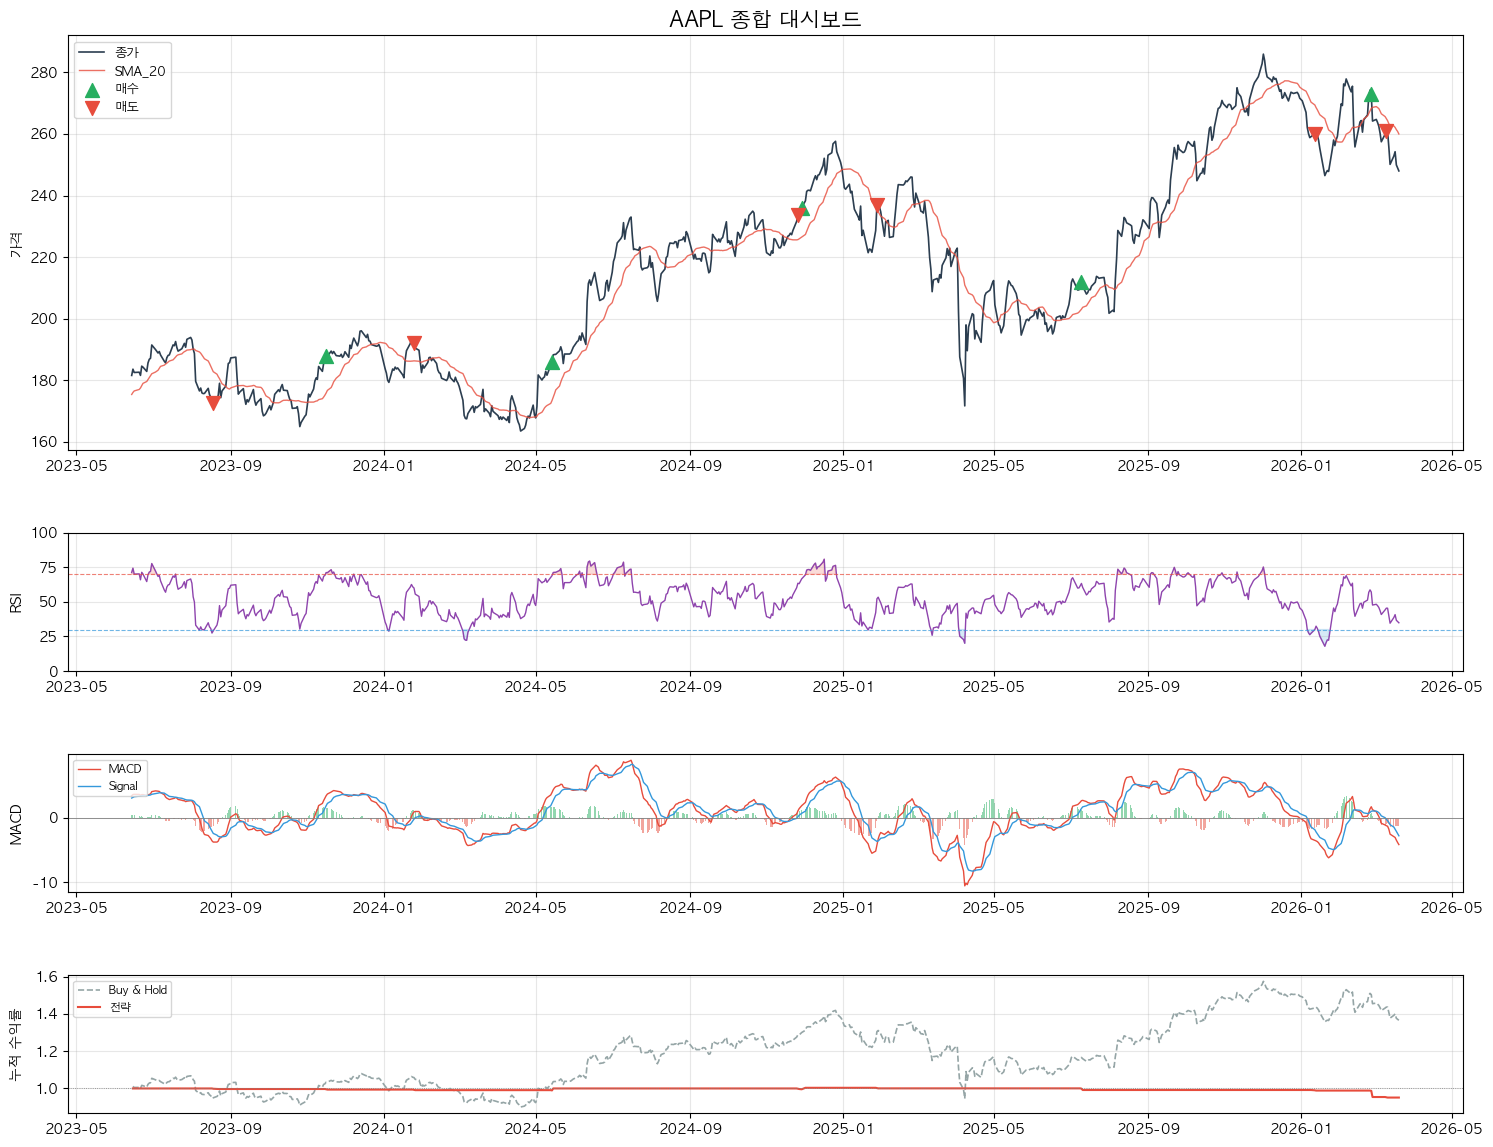

In [10]:
# 종합 대시보드
plot_dashboard(df_result, ticker=TICKER, ma_cols=["SMA_20", "SMA_60"])

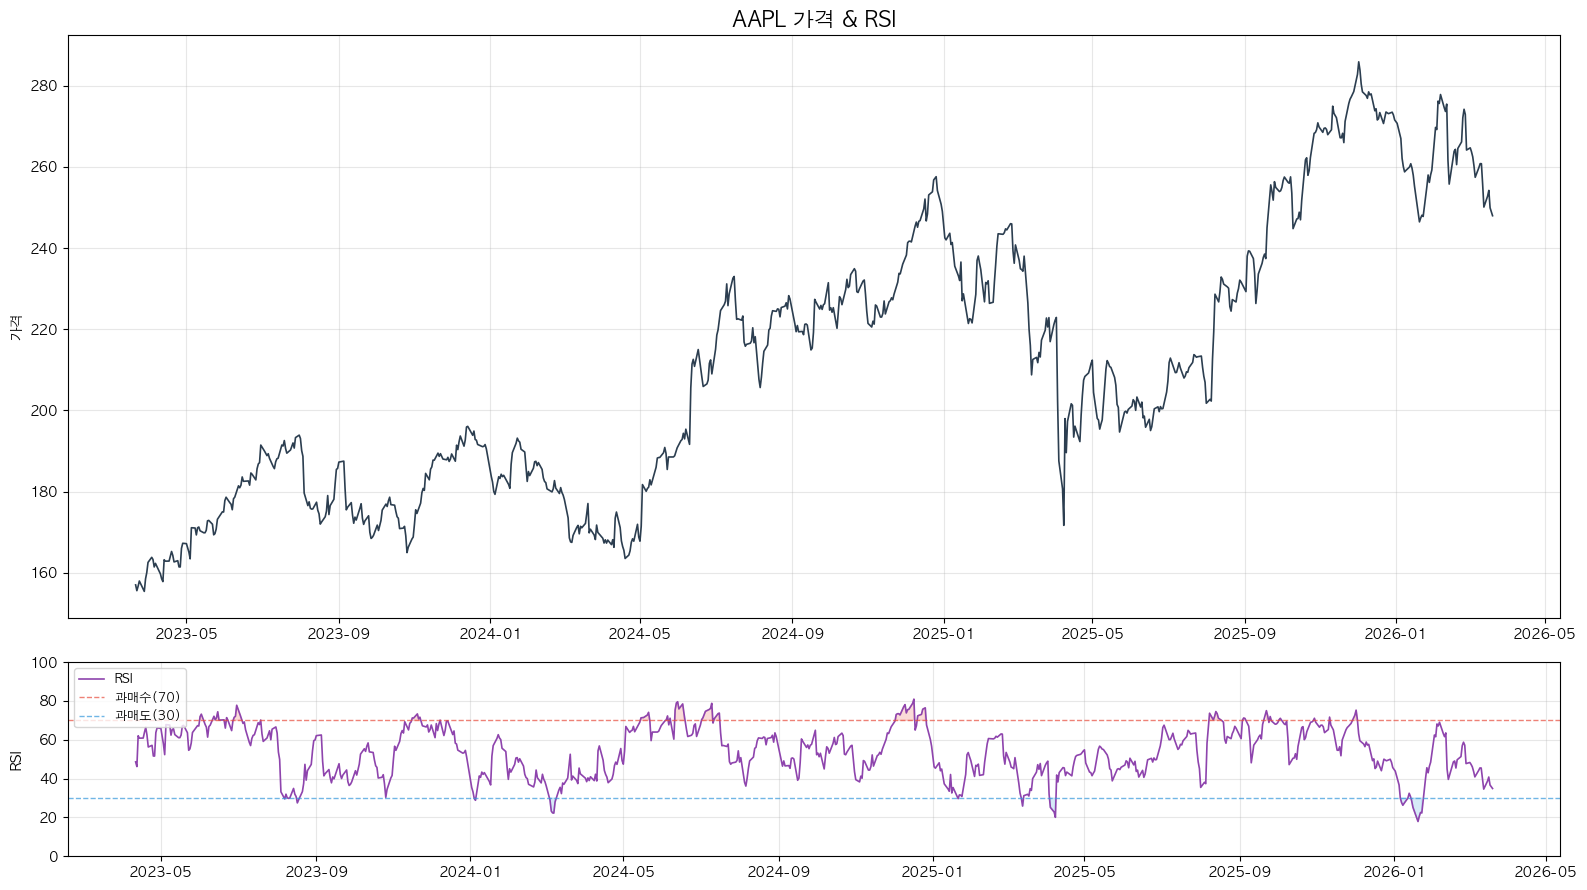

In [11]:
# RSI 차트
plot_rsi(df, ticker=TICKER)

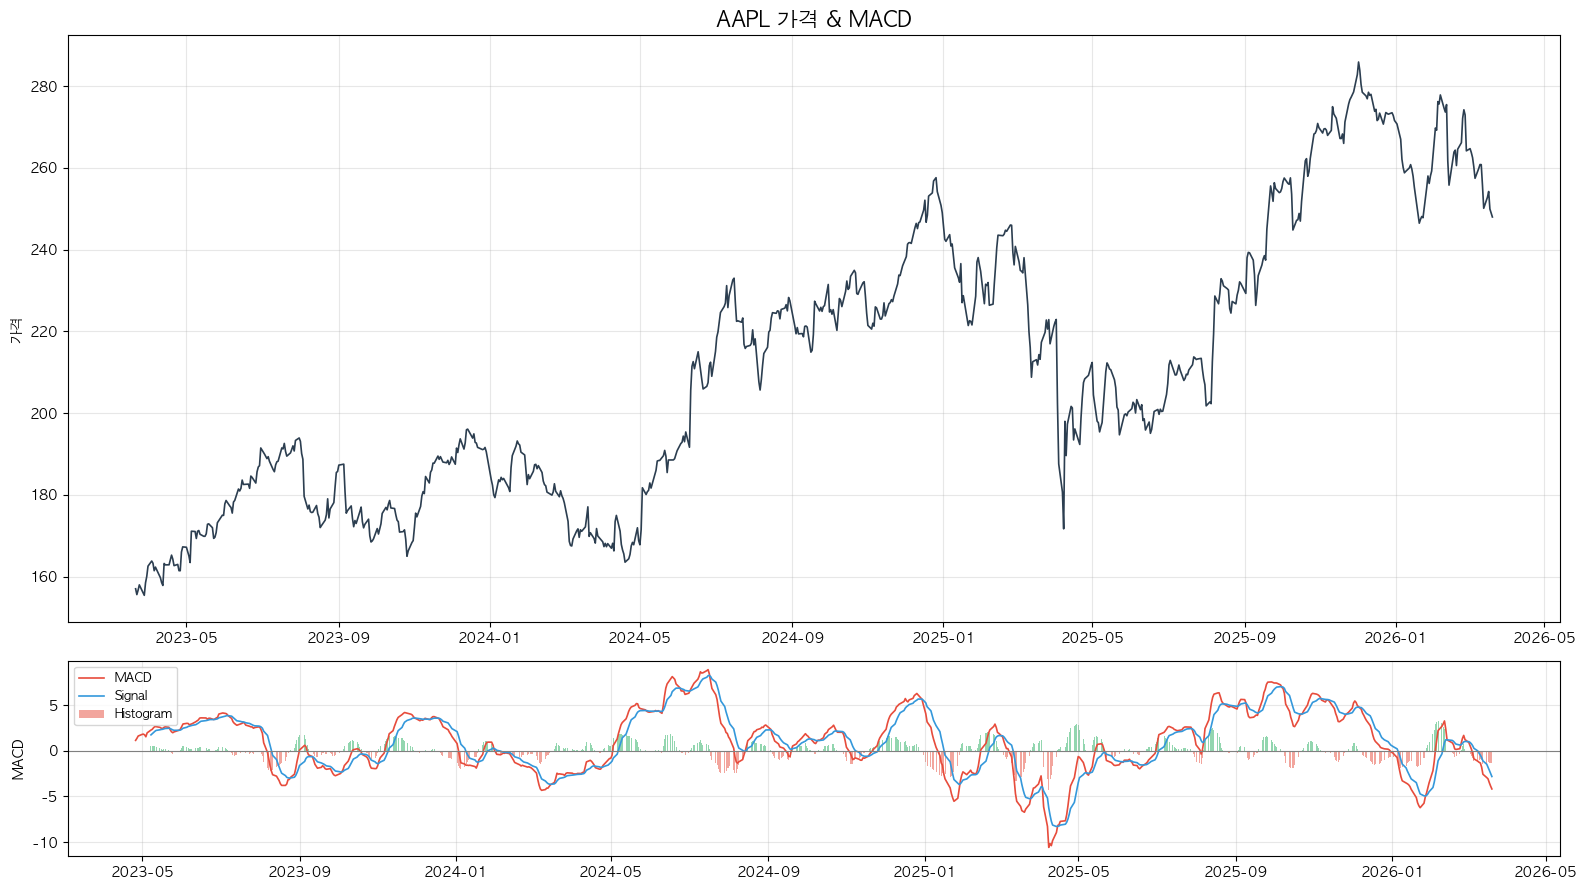

In [12]:
# MACD 차트
plot_macd(df, ticker=TICKER)

지지선: [254.15, 267.01]
저항선: [263.88, 276.71]


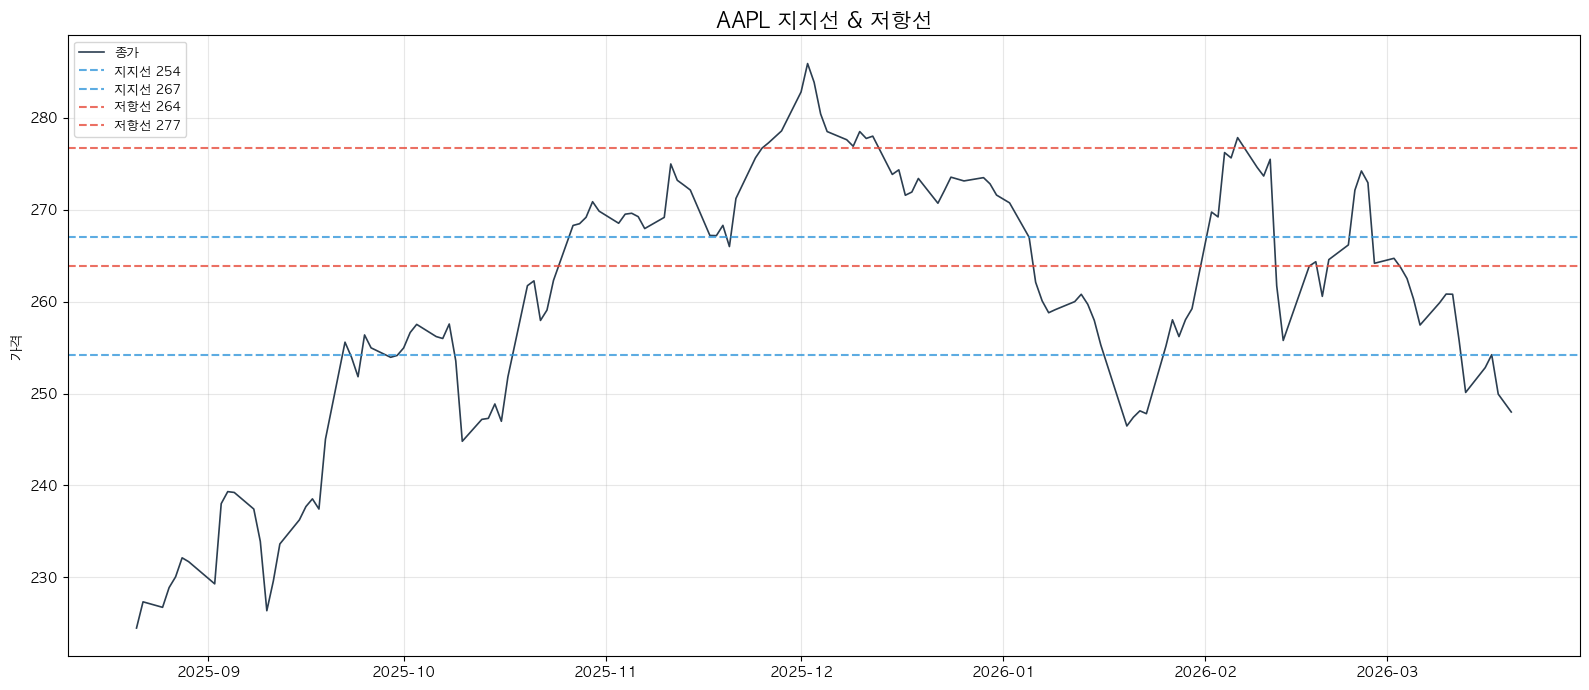

In [13]:
# 지지선 / 저항선
sr = find_support_resistance(df)
print(f"지지선: {sr['support']}")
print(f"저항선: {sr['resistance']}")
plot_support_resistance(df, sr, ticker=TICKER)

고점 25개 / 저점 25개 탐지


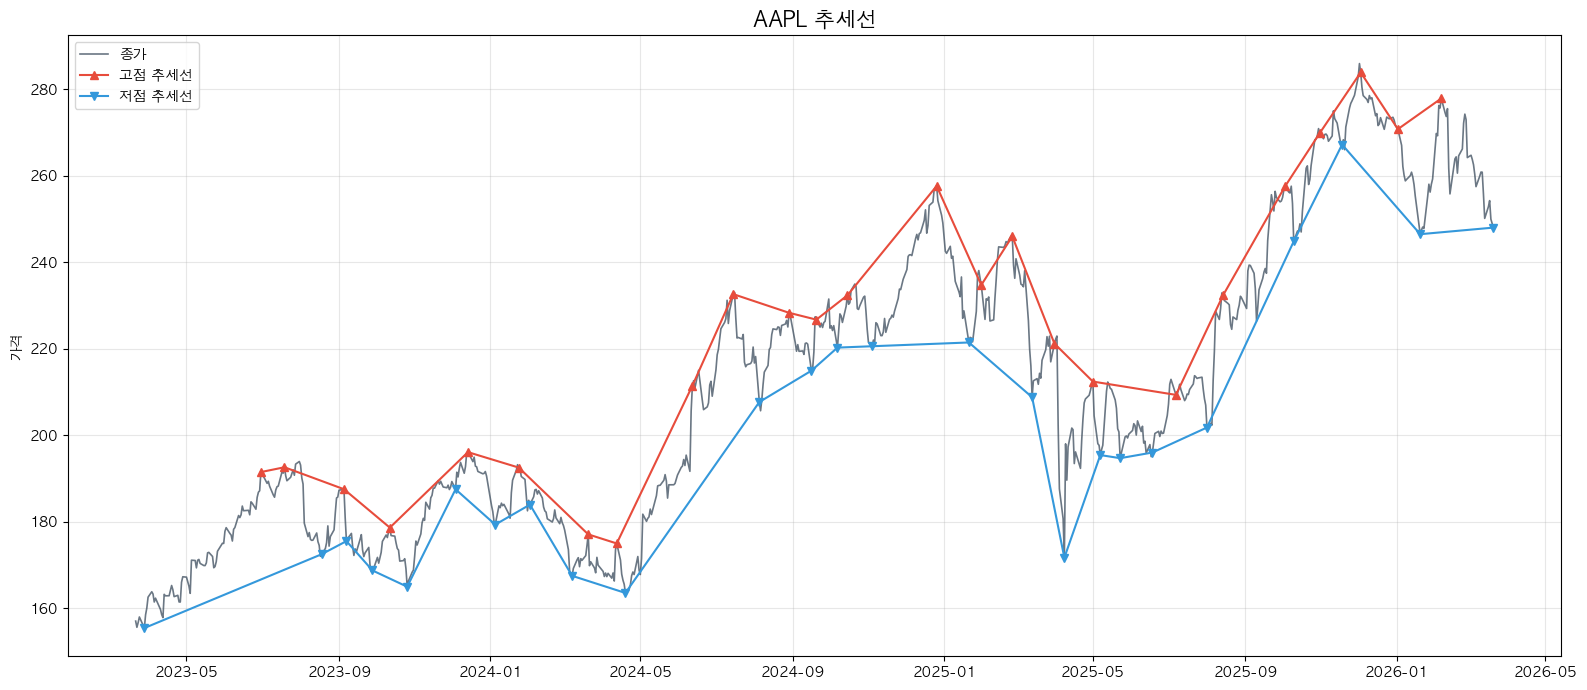

In [14]:
# 추세선
tl = find_trendlines(df)
print(f"고점 {len(tl['highs']['dates'])}개 / 저점 {len(tl['lows']['dates'])}개 탐지")
plot_trendlines(df, tl, ticker=TICKER)

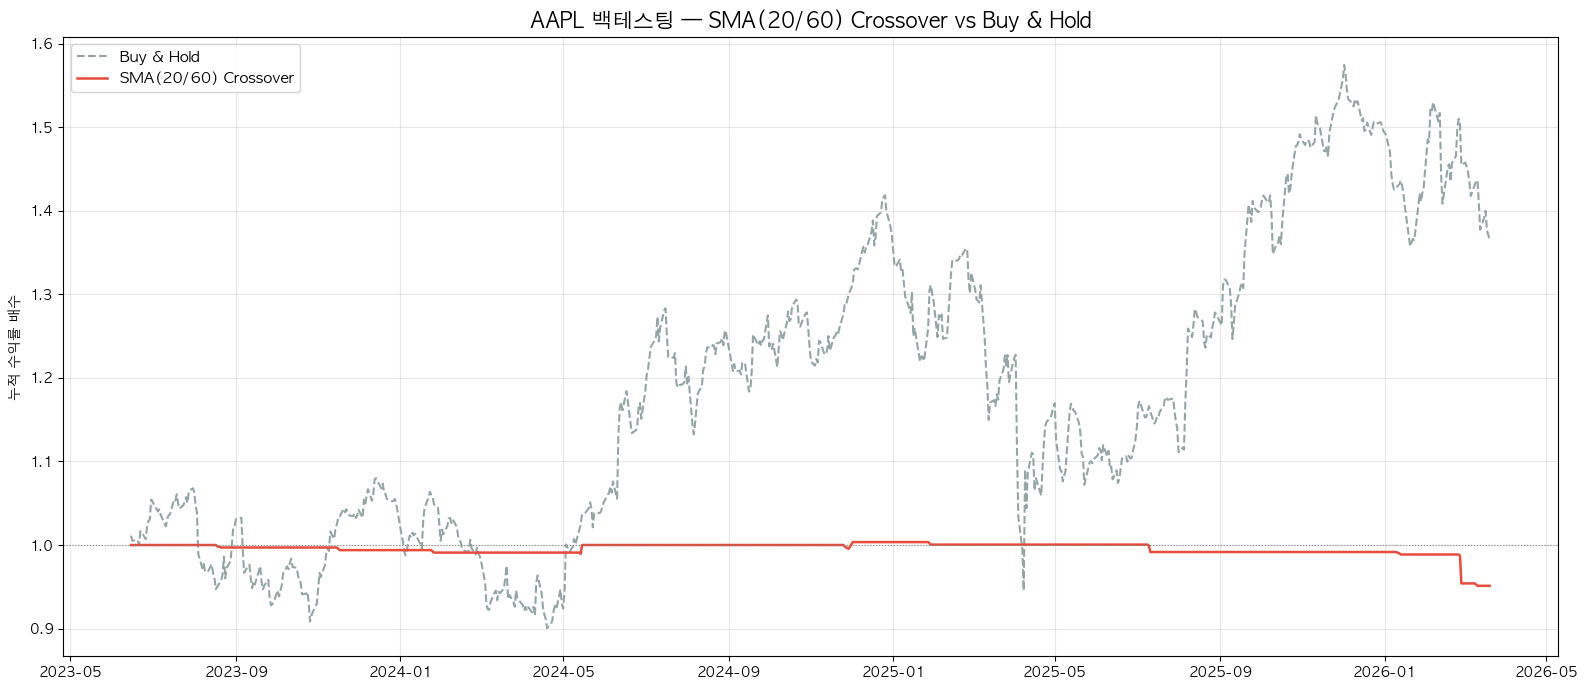

In [15]:
# 전략 vs Buy & Hold 수익률 비교
plot_backtest(df_result, strategy_name=strategy.name, ticker=TICKER)